# Fixed Income Analysis: Bond Pricing and Interest Rate Sensitivity

This notebook demonstrates how to price bonds and analyze their sensitivity to interest rate changes.

Concepts covered:
- Zero-coupon bond pricing
- Coupon bond pricing
- Price-yield relationship
- Duration

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Bond Pricing Function

We implement a function to compute the price of a coupon bond by discounting future cash flows.

In [17]:
def bond_price(face_value, coupon_rate, yield_rate, maturity):
    coupon = face_value * coupon_rate
    price = 0
    
    for t in range(1, maturity + 1):
        price += coupon / (1 + yield_rate) ** t
    
    price += face_value / (1 + yield_rate) ** maturity
    
    return price

In [18]:
face_value = 1000
coupon_rate = 0.05
yield_rate = 0.04
maturity = 10

price = bond_price(face_value, coupon_rate, yield_rate, maturity)

print("Bond Price:", round(price, 2))

Bond Price: 1081.11


## Duration

Duration measures the sensitivity of a bond's price to changes in interest rates.

In [14]:
def bond_duration(face_value, coupon_rate, yield_rate, maturity):

    coupon = face_value * coupon_rate
    duration = 0
    price = bond_price(face_value, coupon_rate, yield_rate, maturity)

    for t in range(1, maturity + 1):
        duration += t * (coupon / (1 + yield_rate) ** t)

    duration += maturity * (face_value / (1 + yield_rate) ** maturity)

    return duration / price


In [15]:
duration = bond_duration(1000,0.05,0.04,10)
print("Bond Duration:", round(duration,2))

Bond Duration: 8.19


## Price–Yield Relationship

Bond prices move inversely to yields. The following graph illustrates this relationship.

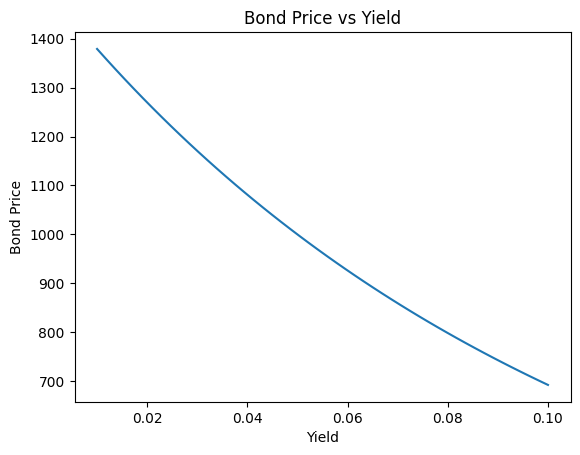

In [16]:
yields = np.linspace(0.01, 0.10, 50)

prices = []

for y in yields:
    prices.append(bond_price(1000, 0.05, y, 10))

plt.plot(yields, prices)
plt.xlabel("Yield")
plt.ylabel("Bond Price")
plt.title("Bond Price vs Yield")
plt.show()